In [41]:
# Nhập thư việnimport numpy as np
import matplotlib.pyplot as plt

In [42]:
# Tạo dữ liệux_train = np.array([1.0, 2.0, 4.0, 3.0, 5.0])
y_train = np.array([300.0, 500.0, 600.0, 450.0, 800.0])

In [43]:
# Kiểm tra dữ liệuprint(f"x_train: {x_train}")
print(f"y_train: {y_train}")
print(f"Số lượng dữ liệu x_train: {x_train.shape}")
print(f"Số lượng dữ liệu y_train: {y_train.shape}")

x_train: [1. 2. 4. 3. 5.]
y_train: [300. 500. 600. 450. 800.]
Số lượng dữ liệu x_train: (5,)
Số lượng dữ liệu y_train: (5,)


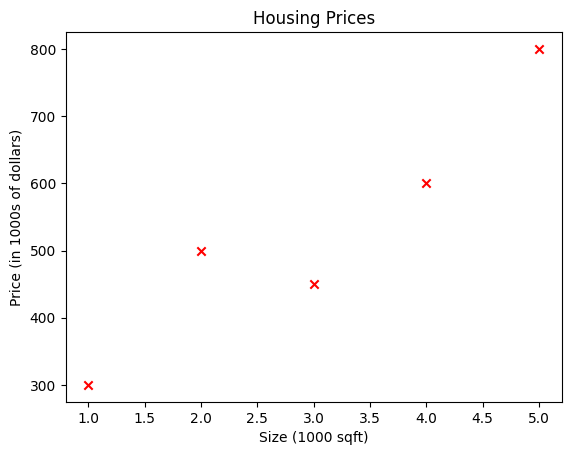

In [44]:
# In dataplt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.show()

In [45]:
# Tạo modeldef compute_model_output(x, w, b):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

In [1]:
# Tính costdef compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i]) ** 2
    total_cost = (1 / (2 * m)) * cost
    return total_cost

In [ ]:
# Tính đạo hàmdef compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw /= m
    dj_db /= m
    return dj_dw, dj_db

In [48]:
# Tính gradient descentimport math, copy

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    w = copy.deepcopy(w_in)
    b = b_in
    J_history = []
    p_history = []
    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            J_history.append(cost_function(x, y, w, b))
            p_history.append([w,b])
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")
    return w, b, J_history, p_history

In [49]:
# Khởi tạow_init = 0
b_init = 0
alpha = 1e-2
num_iters = 10000

In [50]:
# Xe lửaw_final, b_final, J_history, p_history = gradient_descent(x_train, y_train, w_init, b_init, alpha, num_iters, compute_cost, compute_gradient)
print(f"w_final: {w_final: 0.3e}, b_final: {b_final: 0.5e}")

Iteration    0: Cost 1.21e+05  dj_dw: -1.810e+03, dj_db: -5.300e+02   w:  1.810e+01, b: 5.30000e+00
Iteration 1000: Cost 1.78e+03  dj_dw:  1.358e+00, dj_db: -4.902e+00   w:  1.180e+02, b: 1.71052e+02
Iteration 2000: Cost 1.70e+03  dj_dw:  2.501e-01, dj_db: -9.028e-01   w:  1.115e+02, b: 1.94669e+02
Iteration 3000: Cost 1.70e+03  dj_dw:  4.605e-02, dj_db: -1.663e-01   w:  1.103e+02, b: 1.99018e+02
Iteration 4000: Cost 1.70e+03  dj_dw:  8.481e-03, dj_db: -3.062e-02   w:  1.101e+02, b: 1.99819e+02
Iteration 5000: Cost 1.70e+03  dj_dw:  1.562e-03, dj_db: -5.639e-03   w:  1.100e+02, b: 1.99967e+02
Iteration 6000: Cost 1.70e+03  dj_dw:  2.877e-04, dj_db: -1.039e-03   w:  1.100e+02, b: 1.99994e+02
Iteration 7000: Cost 1.70e+03  dj_dw:  5.298e-05, dj_db: -1.913e-04   w:  1.100e+02, b: 1.99999e+02
Iteration 8000: Cost 1.70e+03  dj_dw:  9.757e-06, dj_db: -3.523e-05   w:  1.100e+02, b: 2.00000e+02
Iteration 9000: Cost 1.70e+03  dj_dw:  1.797e-06, dj_db: -6.487e-06   w:  1.100e+02, b: 2.00000e+02


In [57]:
# Dự kiếny_pred = compute_model_output(x_train, w_final, b_final)
print(f"Prediction on training set: {y_pred}")

Prediction on training set: [309.99999489 419.99999685 640.00000076 529.99999881 750.00000272]


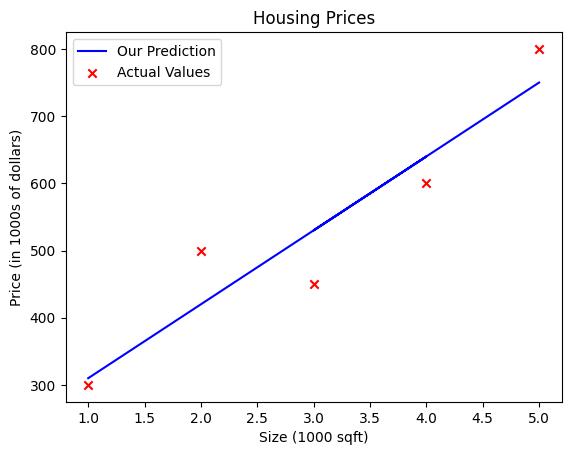

In [ ]:
# Vẽ sơ đồplt.plot(x_train, y_pred, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

In [53]:
# Use sklearn thư việnfrom sklearn.linear_model import LinearRegression

# Tạo mô hìnhmodel = LinearRegression()

# Huấn luyện mô hìnhX_train = x_train.reshape(-1, 1)
model.fit(X_train, y_train)

b = model.intercept_
w = model.coef_

print(f"w = {w:}, b = {b:0.2f}")

w = [110.], b = 200.00


In [55]:
# Dự kiếny_pred = model.predict(X_train)
print(f"Prediction on training set: {y_pred}")

Prediction on training set: [310. 420. 640. 530. 750.]


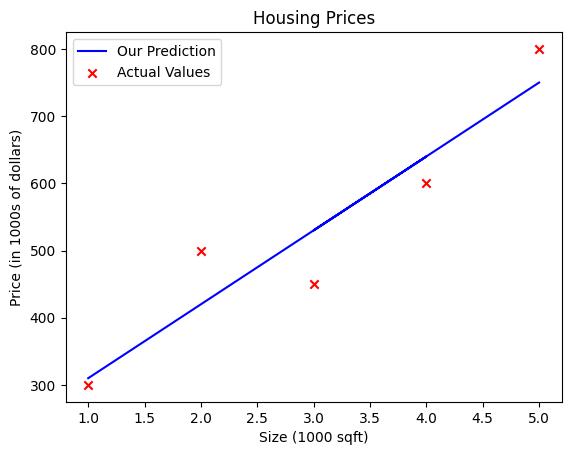

In [ ]:
# Vẽ sơ đồplt.plot(x_train, y_pred, c='b',label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r',label='Actual Values')
plt.title("Housing Prices")
plt.ylabel('Price (in 1000s of dollars)')
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()